# Formative 2: Data Processing and the Product Recommendation Model

This notebook walks through the tabular half of the assignment: taking the two raw customer
datasets, cleaning and merging them into one table, exploring that table, and training the product
recommendation model on it.

The face and voice models and the command-line simulation live in `src/` and are covered by the
test suite; this notebook focuses on the data work (rubric criteria 1 and 2) and the product model.

The code here reuses the functions in `src/` rather than repeating them, so what you see running is
the same code the pipeline and tests use.

In [1]:
%matplotlib inline
import sys
from pathlib import Path

# Find the repo root so `src` is importable no matter where the notebook is launched from.
ROOT = Path.cwd()
while not (ROOT / "src").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import pandas as pd
import matplotlib.pyplot as plt

from src import config, schemas
from src.tabular import merge
from src.models.recommender import TrainedRecommender

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

## 1. The raw data

We are given two datasets. `customer_social_profiles` describes how customers behave on social
media, and `customer_transactions` records what they bought. Neither one on its own is enough to
predict a purchase, so the goal is to combine them.

In [2]:
social = pd.read_csv(config.RAW_TABULAR / "customer_social_profiles.csv")
transactions = pd.read_csv(config.RAW_TABULAR / "customer_transactions.csv")

print("social profiles:", social.shape)
social.head()

social profiles: (155, 5)


,customer_id_new,social_media_platform,engagement_score,purchase_interest_score,review_sentiment
0,A178,LinkedIn,74,4.9,Positive
1,A190,Twitter,82,4.8,Neutral
2,A150,Facebook,96,1.6,Positive
3,A162,Twitter,89,2.6,Positive
4,A197,Twitter,92,2.3,Neutral


In [3]:
print("transactions:", transactions.shape)
transactions.head()

transactions: (150, 6)


,customer_id_legacy,transaction_id,purchase_amount,purchase_date,product_category,customer_rating
0,151,1001,408,2024-01-01,Sports,2.3
1,192,1002,332,2024-01-02,Electronics,4.2
2,114,1003,442,2024-01-03,Electronics,2.1
3,171,1004,256,2024-01-04,Clothing,2.8
4,160,1005,64,2024-01-05,Clothing,1.3


## 2. The join problem

The two files do not share a key. Social profiles identify a customer as `customer_id_new`, a
string like `A178`. Transactions use `customer_id_legacy`, an integer like `178`. Both cover the
range 100 to 199, so the link is to strip the `A` and match on the number.

There is a second issue. Each customer appears on several rows: once per social platform they use,
and once per purchase they made. Joining the two files row by row would multiply these together and
invent data that never existed. So we aggregate each side to one row per customer first, then join
one to one. That also matches what the system needs at run time: after a face and voice identify a
customer, all we know is their id, so the model has to predict from their overall profile.

`src/tabular/merge.py` does this, and its `report()` prints the checks that go into the write-up.

In [4]:
merged = merge.build_merged(social, transactions)
merge.report(social, transactions, merged)

=== inputs
  social profiles     :  155 rows,  84 customers
  transactions        :  150 rows,  75 customers
  exact duplicate rows dropped from social: 5

=== join
  key                 : strip 'A' from customer_id_new, match customer_id_legacy
  customers in both   :  61
  social only, dropped:  23
  transactions only, dropped:  14

=== fan-out avoided
  naive row-level join:  213 rows
  after aggregating   :   61 rows, one per customer

=== output
  rows                : 61
  unique customers    : 61
  nulls               : 0
  target classes      : 5
  target distribution : {'Electronics': 18, 'Books': 14, 'Clothing': 14, 'Sports': 8, 'Groceries': 7}


In [5]:
schemas.validate_merged(merged)
print("merged dataset passes the model contract")
merged.head()

merged dataset passes the model contract


,customer_id,n_transactions,total_spend,mean_purchase_amount,mean_customer_rating,product_category,engagement_score,purchase_interest_score,n_platforms,primary_platform,review_sentiment
0,100,2,559,279.500000,4.300000,Books,77.000000,4.400000,2,Instagram,Negative
1,101,4,1016,254.000000,2.525000,Books,68.000000,1.000000,1,Twitter,Neutral
2,102,3,569,189.666667,3.433333,Electronics,51.000000,4.800000,1,LinkedIn,Neutral
3,103,3,797,265.666667,4.200000,Sports,64.333333,2.866667,2,Instagram,Positive
4,104,2,698,349.000000,1.450000,Clothing,83.000000,2.933333,2,Twitter,Negative


## 3. Exploratory data analysis

Before modelling, we look at the merged table: what the variables are, whether anything is missing,
how the numeric features are spread, and how they relate to each other.

In [6]:
print("variable types:")
for col in merged.columns:
    kind = "numeric" if pd.api.types.is_numeric_dtype(merged[col]) else "categorical"
    if col == schemas.MERGED_ID_COLUMN:
        kind = "identifier"
    if col == schemas.MERGED_TARGET_COLUMN:
        kind = "target"
    print(f"  {col:<26} {kind}")

print("\nmissing values:", int(merged.isna().sum().sum()))

variable types:
  customer_id                identifier
  n_transactions             numeric
  total_spend                numeric
  mean_purchase_amount       numeric
  mean_customer_rating       numeric
  product_category           target
  engagement_score           numeric
  purchase_interest_score    numeric
  n_platforms                numeric
  primary_platform           categorical
  review_sentiment           categorical

missing values: 0


In [7]:
# customer_id is an identifier, not a feature, so leave it out of the numeric summary.
numeric = [c for c in merged.select_dtypes("number").columns if c != schemas.MERGED_ID_COLUMN]
merged[numeric].describe().round(2)

,n_transactions,total_spend,mean_purchase_amount,mean_customer_rating,engagement_score,purchase_interest_score,n_platforms
count,61.00,61.00,61.00,61.00,61.00,61.00,61.00
mean,1.92,552.21,281.55,3.11,74.23,3.08,1.56
std,0.97,340.62,94.57,1.04,13.14,1.02,0.70
min,1.00,64.00,64.00,1.10,50.00,1.00,1.00
25%,1.00,286.00,216.50,2.52,66.50,2.67,1.00
50%,2.00,460.00,279.50,2.98,75.00,3.13,1.00
75%,2.00,764.00,364.00,3.86,83.00,3.82,2.00
max,5.00,1863.00,465.00,5.00,99.00,4.80,4.00


### Plot 1: the prediction target

`product_category` is what the model predicts. It is uneven: Electronics is the most common class,
so any model has to beat the "always guess Electronics" baseline to be worth anything.

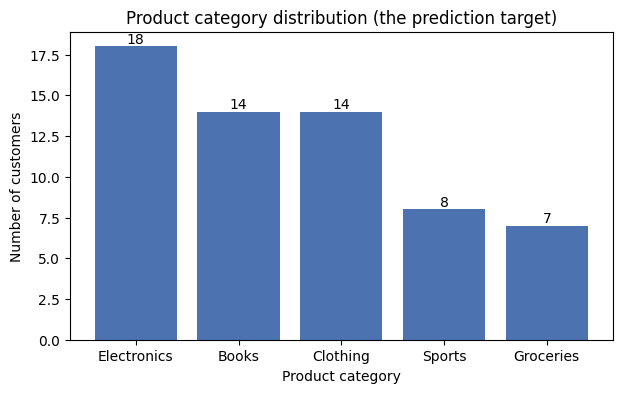

majority-class baseline: 30%


In [8]:
counts = merged[schemas.MERGED_TARGET_COLUMN].value_counts()

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(counts.index, counts.values, color="#4c72b0")
ax.set_title("Product category distribution (the prediction target)")
ax.set_xlabel("Product category")
ax.set_ylabel("Number of customers")
for i, v in enumerate(counts.values):
    ax.text(i, v + 0.2, str(v), ha="center")
plt.show()

print(f"majority-class baseline: {counts.max() / len(merged):.0%}")

### Plot 2: spread and outliers of the numeric features

The features are on very different scales (spend is in the hundreds, ratings are 1 to 5), so we
standardise them to compare on one axis. A few customers show up as outliers on `total_spend` and
`n_transactions`; these are real high-activity customers, not errors, so we keep them.

/var/folders/8p/b_cj65j96fz4h47rt8tp35080000gp/T/ipykernel_39836/890608867.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(standardised.values, labels=numeric, vert=True)


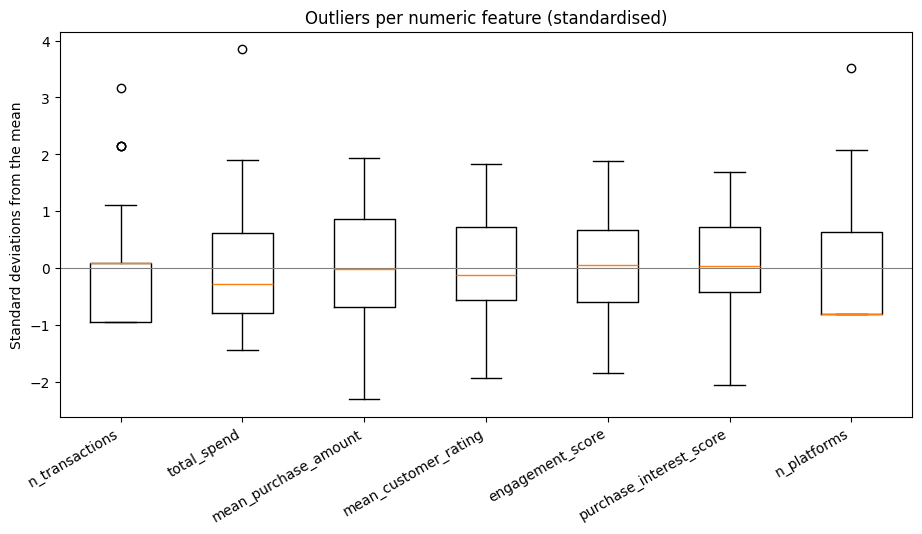

In [9]:
standardised = (merged[numeric] - merged[numeric].mean()) / merged[numeric].std()

fig, ax = plt.subplots(figsize=(11, 5))
ax.boxplot(standardised.values, labels=numeric, vert=True)
ax.set_title("Outliers per numeric feature (standardised)")
ax.set_ylabel("Standard deviations from the mean")
ax.axhline(0, color="grey", linewidth=0.8)
plt.xticks(rotation=30, ha="right")
plt.show()

### Plot 3: correlation between features

This is the plot that explains the model's performance. The only strong relationships are among the
transaction features (`n_transactions` and `total_spend`). The social features (engagement,
purchase interest, sentiment) barely correlate with anything, which is a warning that they may not
predict the product category well.

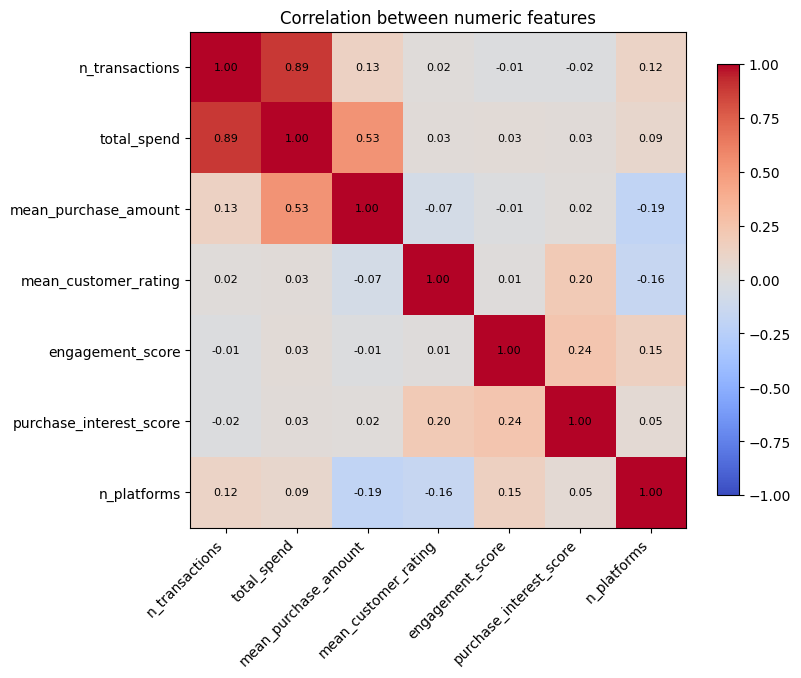

In [10]:
corr = merged[numeric].corr()

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(numeric)))
ax.set_yticks(range(len(numeric)))
ax.set_xticklabels(numeric, rotation=45, ha="right")
ax.set_yticklabels(numeric)
for i in range(len(numeric)):
    for j in range(len(numeric)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8)
ax.set_title("Correlation between numeric features")
fig.colorbar(im, ax=ax, shrink=0.8)
plt.show()

## 4. The product recommendation model

The model is a random forest that predicts `product_category` from the merged features. Categorical
columns (platform, sentiment) are one-hot encoded so the forest can use them.

We evaluate with 5-fold cross-validation grouped by customer, so a customer never appears in both
the training and test folds. The metrics below are honest out-of-sample numbers, not the model
scoring data it has already seen.

In [11]:
model = TrainedRecommender()
metrics = model.cross_validate(merged)

baseline = merged[schemas.MERGED_TARGET_COLUMN].value_counts(normalize=True).max()

print("product recommendation model (5-fold grouped CV):")
print(f"  accuracy : {metrics.accuracy:.3f}")
print(f"  f1_macro : {metrics.f1_macro:.3f}")
print(f"  log_loss : {metrics.log_loss:.3f}")
print(f"\nmajority-class baseline accuracy: {baseline:.3f}")

product recommendation model (5-fold grouped CV):
  accuracy : 0.328
  f1_macro : 0.242
  log_loss : 1.678

majority-class baseline accuracy: 0.295


The accuracy is modest and only a little above the baseline. That is the honest result on this data:
61 customers across 5 categories is very little signal, and the correlation plot already showed the
social features barely relate to the target. We report this as it is rather than inflating it. In
the report we note this as a limitation and a place more data would help.

Once trained on the full dataset, the model looks a customer up by id and returns a recommendation.
This is what the system calls after a face and voice authenticate someone.

In [12]:
model.fit(merged)
example_id = merged[schemas.MERGED_ID_COLUMN].iloc[0]
print(f"recommendation for customer {example_id}: {model.recommend(str(example_id))}")

recommendation for customer 100: Books (75% confidence)


## 5. Where this fits in the whole system

This notebook covered the tabular pipeline and the product model. The complete system adds two more
models and a command-line simulation, all in `src/`:

- **Face recognition** and **voiceprint verification** (`src/models/biometric.py`): identify a team
  member from image and audio features. These train once Taps and Tedla deliver
  `image_features.csv` and `audio_features.csv`.
- **The multimodal gate** (`src/models/decision.py`): face first, then voice, and the voice must
  identify the same person the face did. Only then does the identity registry resolve the person to
  a customer id and call the product model above.
- **The simulation** (`src/cli/app.py`): runs a full transaction end to end, plus an unauthorized
  attempt.

Run the whole thing with `python -m src.train` to train all three models, then
`python -m src.cli.app --face ... --voice ...` for a transaction. The test suite (`pytest tests/`)
covers all of it.